<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn6face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 성인 남녀 얼굴 이미지 분류 (이진) - data는 구글 드라이브에 있음
# 파일명에 label로 사용할 힌트가 있음

import os, cv2, numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

image_dir = '/content/drive/MyDrive/Colab Notebooks/person_img'
x, y = [], []
# 레이블 구하기 : 30_0_0_20170119195539771.jpg
# gender = int(파일명.split('_')[1])  0 -> male, 1 -> female

for file in os.listdir(image_dir):
  try:
    gender = int(file.split('_')[1])
    img_path = os.path.join(image_dir, file)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (64, 64))
    x.append(img)
    y.append(gender)
  except:
    continue

print(x[0])
print(y[0])

[[[ 72 117 161]
  [ 91 140 172]
  [117 161 184]
  ...
  [119 166 188]
  [164 186 198]
  [202 208 213]]

 [[173 197 209]
  [109 125 132]
  [166 173 179]
  ...
  [172 190 207]
  [183 190 205]
  [188 189 199]]

 [[124 169 160]
  [ 92 167 151]
  [109 189 176]
  ...
  [163 180 189]
  [171 183 193]
  [179 189 199]]

 ...

 [[ 51 135 100]
  [ 45 121  94]
  [ 35 121  96]
  ...
  [248 240 237]
  [255 243 237]
  [245 226 213]]

 [[ 39 128  88]
  [ 70 150 119]
  [ 36 126  96]
  ...
  [252 246 246]
  [253 248 245]
  [247 240 231]]

 [[ 44 136  93]
  [ 71 157 123]
  [ 38 135 101]
  ...
  [255 250 252]
  [254 255 253]
  [248 249 245]]]
0


Text(0.5, 1.0, 'label : 0(male)')

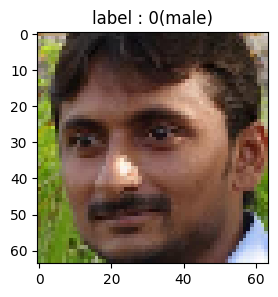

In [ ]:
# 첫번째 이미지 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3))
img_rgb = cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB)   # matplotlib:RGB, opencv:BGR
plt.imshow(img_rgb)
plt.title(f'label : {y[0]}({'male' if y[0] == 0 else 'female'})')

In [3]:
# 정규화
x = np.array(x) / 255.0
y = np.array(y)

# trian / test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(102, 64, 64, 3) (26, 64, 64, 3)


In [4]:
# 모델 생성
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
# compile / fit
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=2)
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'test acc : {acc:.4f}')

Epoch 1/20
3/3 - 7s - 2s/step - accuracy: 0.6420 - loss: 0.6880 - val_accuracy: 0.7143 - val_loss: 0.6132
Epoch 2/20
3/3 - 0s - 31ms/step - accuracy: 0.7407 - loss: 0.5751 - val_accuracy: 0.7143 - val_loss: 0.5804
Epoch 3/20
3/3 - 0s - 48ms/step - accuracy: 0.7407 - loss: 0.5189 - val_accuracy: 0.7143 - val_loss: 0.5861
Epoch 4/20
3/3 - 0s - 31ms/step - accuracy: 0.7654 - loss: 0.4824 - val_accuracy: 0.7619 - val_loss: 0.5924
Epoch 5/20
3/3 - 0s - 31ms/step - accuracy: 0.8765 - loss: 0.4142 - val_accuracy: 0.7143 - val_loss: 0.6373
Epoch 6/20
3/3 - 0s - 30ms/step - accuracy: 0.7654 - loss: 0.4152 - val_accuracy: 0.7619 - val_loss: 0.6236
Epoch 7/20
3/3 - 0s - 44ms/step - accuracy: 0.9259 - loss: 0.3547 - val_accuracy: 0.7619 - val_loss: 0.6405
Epoch 8/20
3/3 - 0s - 30ms/step - accuracy: 0.8889 - loss: 0.3013 - val_accuracy: 0.8095 - val_loss: 0.7044
Epoch 9/20
3/3 - 0s - 34ms/step - accuracy: 0.9259 - loss: 0.2627 - val_accuracy: 0.5238 - val_loss: 0.7819
Epoch 10/20
3/3 - 0s - 29ms/st

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
예측값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
실제값 : [1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0]


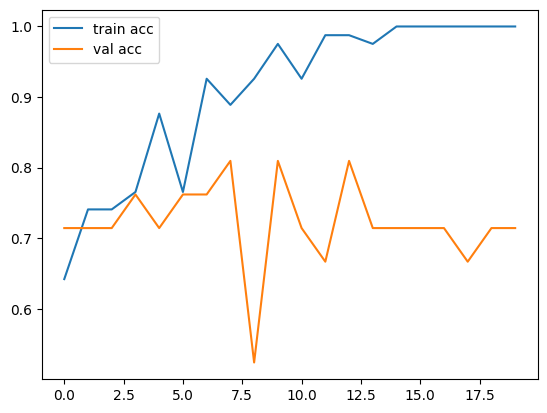

In [6]:
# 예측하기
pred = model.predict(x_test)
print(f'예측값 : {(pred >=5).astype(int).reshape(-1)}')
print(f'실제값 : {y_test}')

# acc에 대한 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


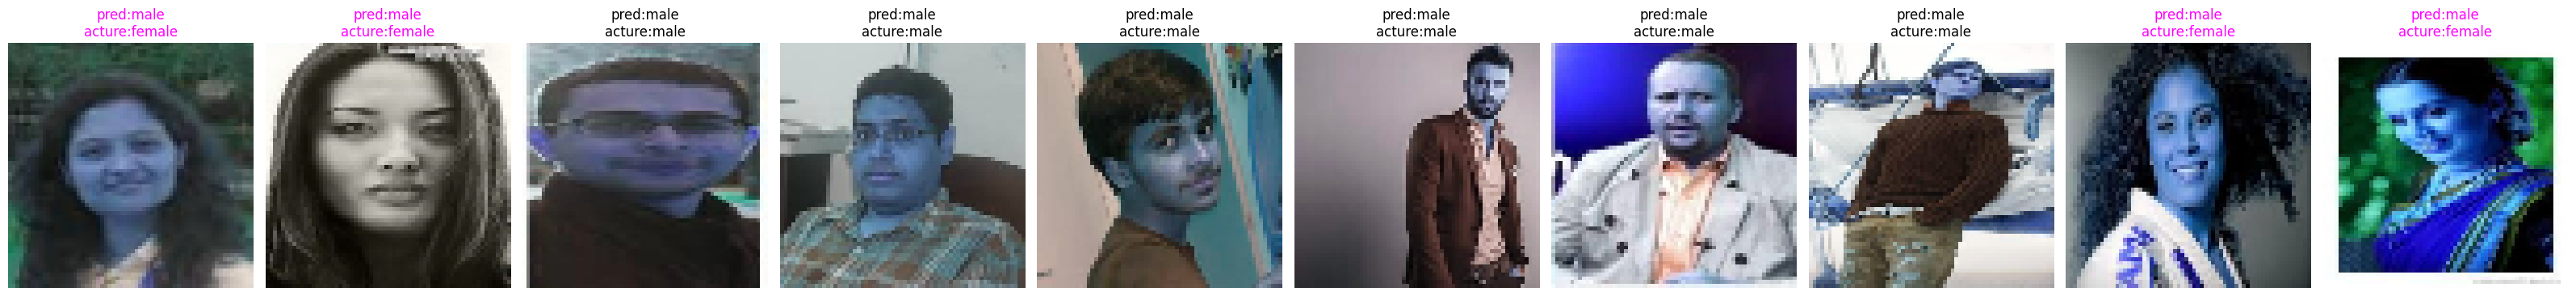

In [9]:
# 5개의 이미지로 분류 예측 시각화
pred = model.predict(x_test[:10])
pred_classes = (pred >= 0.5).astype(int).reshape(-1)
true_classes = y_test[:10]

plt.figure(figsize=(32, 4))
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(x_test[i])

  is_correct = pred_classes[i] == true_classes[i]
  label = 'female' if true_classes[i] == 1 else 'male'
  prediction = 'female' if pred_classes[i] == 1 else 'male'
  title_color = 'black' if is_correct else 'magenta'
  plt.title(f'pred:{prediction}\nacture:{label}', color=title_color)
  plt.axis('off')
plt.tight_layout()
plt.show()

# 현재 모델은 학습데이터 부족으로 좋은 결과를 기대하기 어렵다.